# Polish Apartment Price Prediction
**Data:** 28,310 listings scraped from Otodom.pl — 15 Polish cities, March 2026  
**Goal:** Predict sale price using XGBoost regression; interpret with SHAP  
**Pipeline:** scrape → clean → EDA → feature engineering → XGBoost → SHAP → Streamlit app


In [ ]:
from __future__ import annotations

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.2f}".format)
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})

SEED = 17
np.random.seed(SEED)
print("imports ok")


imports ok


## Data Loading


In [ ]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

DATA_PATH = "/content/drive/MyDrive/housing-scraper/data/raw/otodom_all.csv"

df_raw = pd.read_csv(DATA_PATH)
print(f"Shape   : {df_raw.shape}")
print(f"Columns : {list(df_raw.columns)}")
print()
print(df_raw.head(3).to_string())


Mounted at /content/drive
Shape   : (28934, 10)
Columns : ['city', 'price', 'price_per_m2', 'area_m2', 'rooms', 'floor', 'neighborhood', 'sub_neighborhood', 'is_private_owner', 'url']

       city      price  price_per_m2  area_m2  rooms  floor    neighborhood sub_neighborhood  is_private_owner                                                                                  url
0  Warszawa 1149000.00      22512.00    51.04   2.00   4.00         Mokotów           Stegny             False  https://www.otodom.pl/pl/oferta/2-pok-w-wysokim-standardzie-2-balkony-klima-ID4ApOc
1  Warszawa 1034000.00      17951.00    57.60   4.00   3.00  Praga-Południe       Saska Kępa             False        https://www.otodom.pl/pl/oferta/saska-kepa-4-pokoje-super-lokalizacja-ID4ADxr
2  Warszawa  739000.00      16242.00    45.50   2.00   1.00            Wola             Koło             False      https://www.otodom.pl/pl/oferta/park-moczydlo-wola-kolo-2-osobne-pokoje-ID4ADFJ


## Data Cleaning


In [ ]:
df = df_raw.drop(columns=["url", "sub_neighborhood"]).copy()

df["is_private_owner"] = df["is_private_owner"].astype(bool)

df = df.dropna(subset=["price", "area_m2"])
df = df[(df["price"] >= 50_000) & (df["price"] <= 5_000_000)]
df = df[(df["area_m2"] >= 15)   & (df["area_m2"] <= 250)]

df["price_per_m2"] = df["price"] / df["area_m2"]

PPM2_CAP = 40_000
df = df[df["price_per_m2"] <= PPM2_CAP].reset_index(drop=True)

df["log_price"] = np.log1p(df["price"])

print(f"Rows after cleaning : {len(df)}  (dropped {len(df_raw) - len(df)})")
print()
print("Null % per column:")
print(df.isna().mean().mul(100).round(1).to_string())
print()
print(f"price     skew: {df['price'].skew():.2f}")
print(f"log_price skew: {df['log_price'].skew():.2f}")


Rows after cleaning : 28310  (dropped 624)

Null % per column:
city               0.00
price              0.00
price_per_m2       0.00
area_m2            0.00
rooms              0.70
floor              5.20
neighborhood       0.90
is_private_owner   0.00
log_price          0.00

price     skew: 2.93
log_price skew: 0.55


## Exploratory Data Analysis
### Price distribution


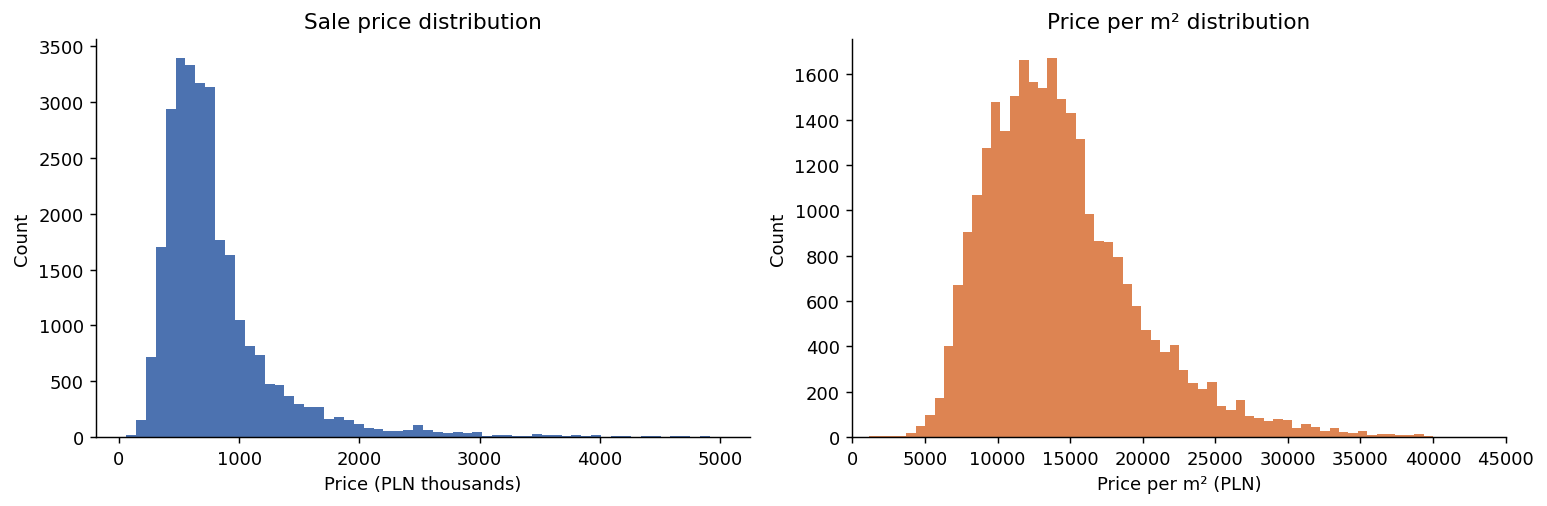

[saved] price_distribution.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["price"] / 1_000, bins=60, color="#4C72B0", edgecolor="none")
axes[0].set_xlabel("Price (PLN thousands)")
axes[0].set_ylabel("Count")
axes[0].set_title("Sale price distribution")

axes[1].hist(df["price_per_m2"], bins=60, color="#DD8452", edgecolor="none")
axes[1].set_xlabel("Price per m² (PLN)")
axes[1].set_ylabel("Count")
axes[1].set_title("Price per m² distribution")
axes[1].set_xlim(0, 45_000)

plt.tight_layout()
plt.savefig("price_distribution.png", bbox_inches="tight")
plt.show()
print("[saved] price_distribution.png")


### Median price per m² by city


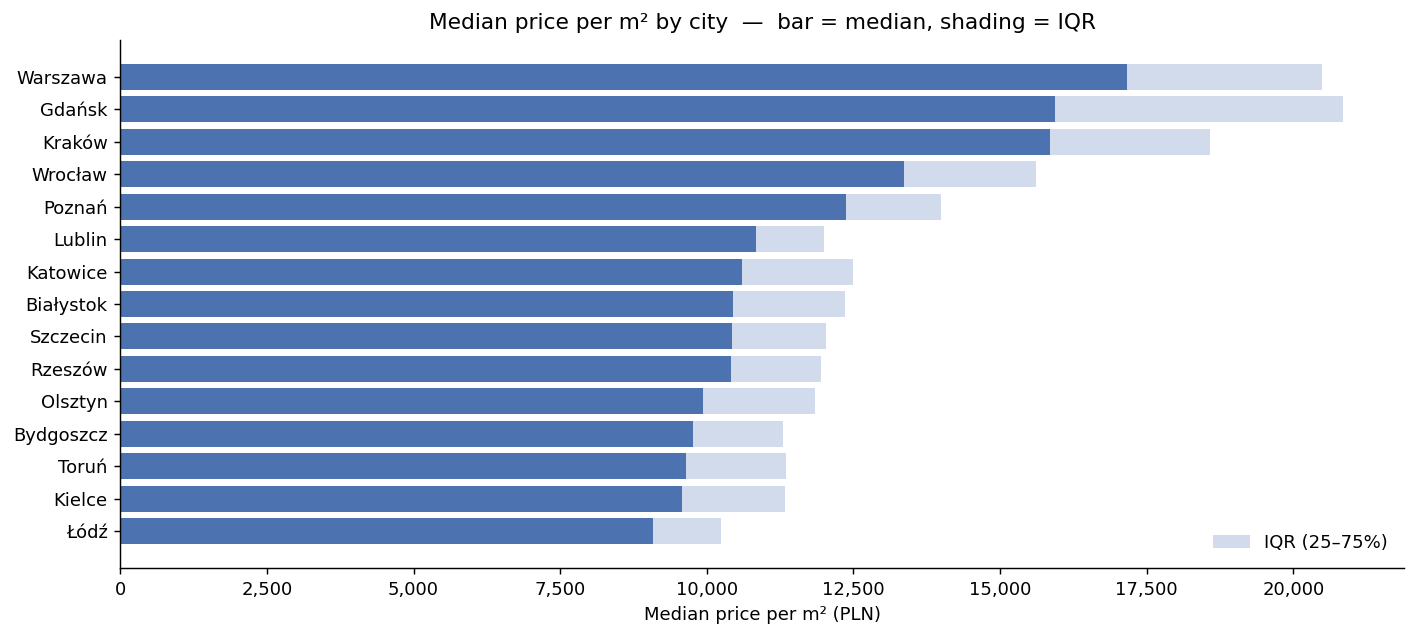

[saved] city_price_per_m2.png

     city   median      q25      q75  count
 Warszawa 17156.49 14613.69 20490.39   7387
   Gdańsk 15941.18 12300.00 20845.07   1901
   Kraków 15858.35 13981.82 18573.85   4454
  Wrocław 13358.49 11545.07 15607.57   3684
   Poznań 12369.15 11000.00 14000.00   1939
   Lublin 10842.11  9799.71 11993.52    839
 Katowice 10600.00  8311.67 12500.00    507
Białystok 10449.95  8924.43 12356.76    789
 Szczecin 10432.84  8932.85 12037.53    809
  Rzeszów 10416.67  9200.00 11941.49    523
  Olsztyn  9935.99  8500.00 11848.96    509
Bydgoszcz  9769.77  8042.91 11299.46    854
    Toruń  9652.61  8422.22 11349.98    677
   Kielce  9571.16  8067.51 11336.59    747
     Łódź  9075.91  7808.30 10238.26   2691


In [ ]:
city_stats = (
    df.groupby("city")["price_per_m2"]
    .agg(median="median", q25=lambda x: x.quantile(0.25), q75=lambda x: x.quantile(0.75), count="count")
    .sort_values("median", ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(city_stats["city"], city_stats["median"], color="#4C72B0", zorder=2)
ax.barh(
    city_stats["city"],
    city_stats["q75"] - city_stats["q25"],
    left=city_stats["q25"],
    color="#4C72B0", alpha=0.25, zorder=1, label="IQR (25–75%)"
)
ax.set_xlabel("Median price per m² (PLN)")
ax.set_title("Median price per m² by city  —  bar = median, shading = IQR")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(frameon=False)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("city_price_per_m2.png", bbox_inches="tight")
plt.show()
print("[saved] city_price_per_m2.png")
print()
print(city_stats[["city", "median", "q25", "q75", "count"]].to_string(index=False))


### Price vs area


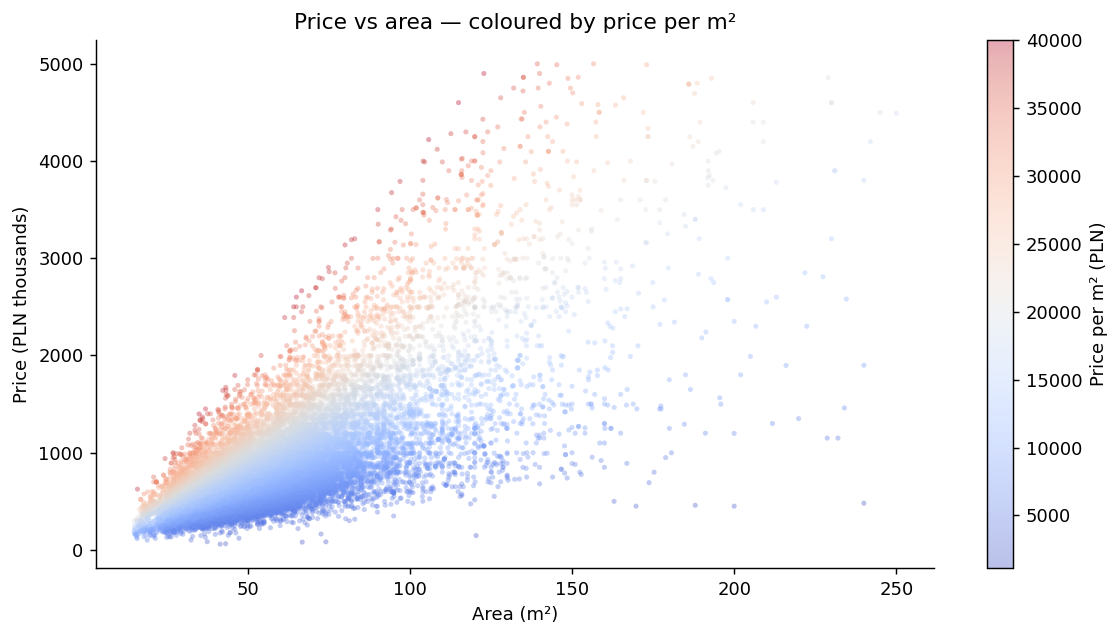

[saved] price_vs_area.png


In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

scatter = ax.scatter(
    df["area_m2"], df["price"] / 1_000,
    c=df["price_per_m2"], cmap="coolwarm",
    alpha=0.35, s=8, linewidths=0,
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Price per m² (PLN)")

ax.set_xlabel("Area (m²)")
ax.set_ylabel("Price (PLN thousands)")
ax.set_title("Price vs area — coloured by price per m²")

plt.tight_layout()
plt.savefig("price_vs_area.png", bbox_inches="tight")
plt.show()
print("[saved] price_vs_area.png")


### Median price per m² by number of rooms


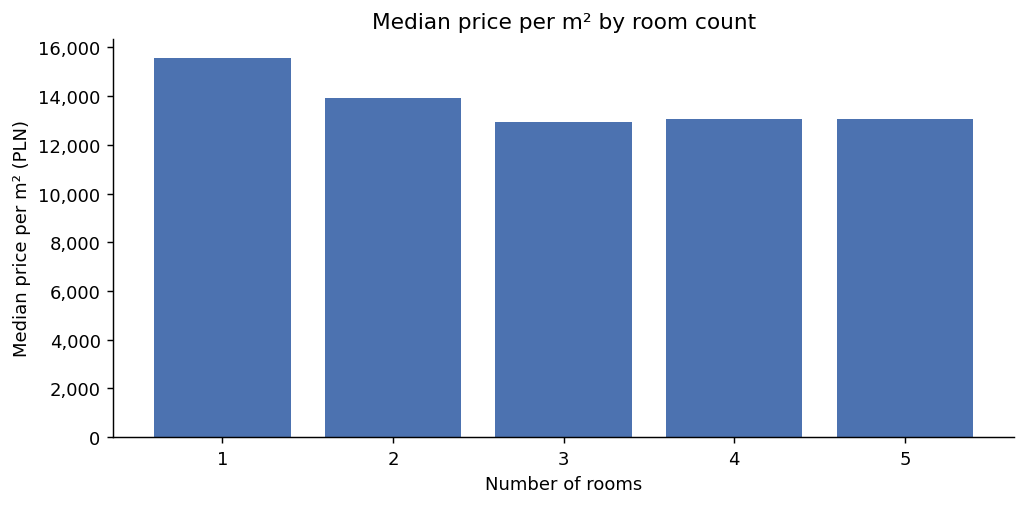

[saved] price_by_rooms.png

 rooms   median  count
     1 15573.77   3031
     2 13930.35  11237
     3 12949.90   9720
     4 13068.18   3443
     5 13078.27    693


In [ ]:
rooms_stats = (
    df.dropna(subset=["rooms"])
    .groupby("rooms")["price_per_m2"]
    .agg(median="median", count="count")
    .reset_index()
    .astype({"rooms": int})
    .sort_values("rooms")
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(rooms_stats["rooms"].astype(str), rooms_stats["median"], color="#4C72B0", edgecolor="none")
ax.set_xlabel("Number of rooms")
ax.set_ylabel("Median price per m² (PLN)")
ax.set_title("Median price per m² by room count")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.savefig("price_by_rooms.png", bbox_inches="tight")
plt.show()
print("[saved] price_by_rooms.png")
print()
print(rooms_stats.to_string(index=False))


### Median price per m² by neighborhood — top 5 cities


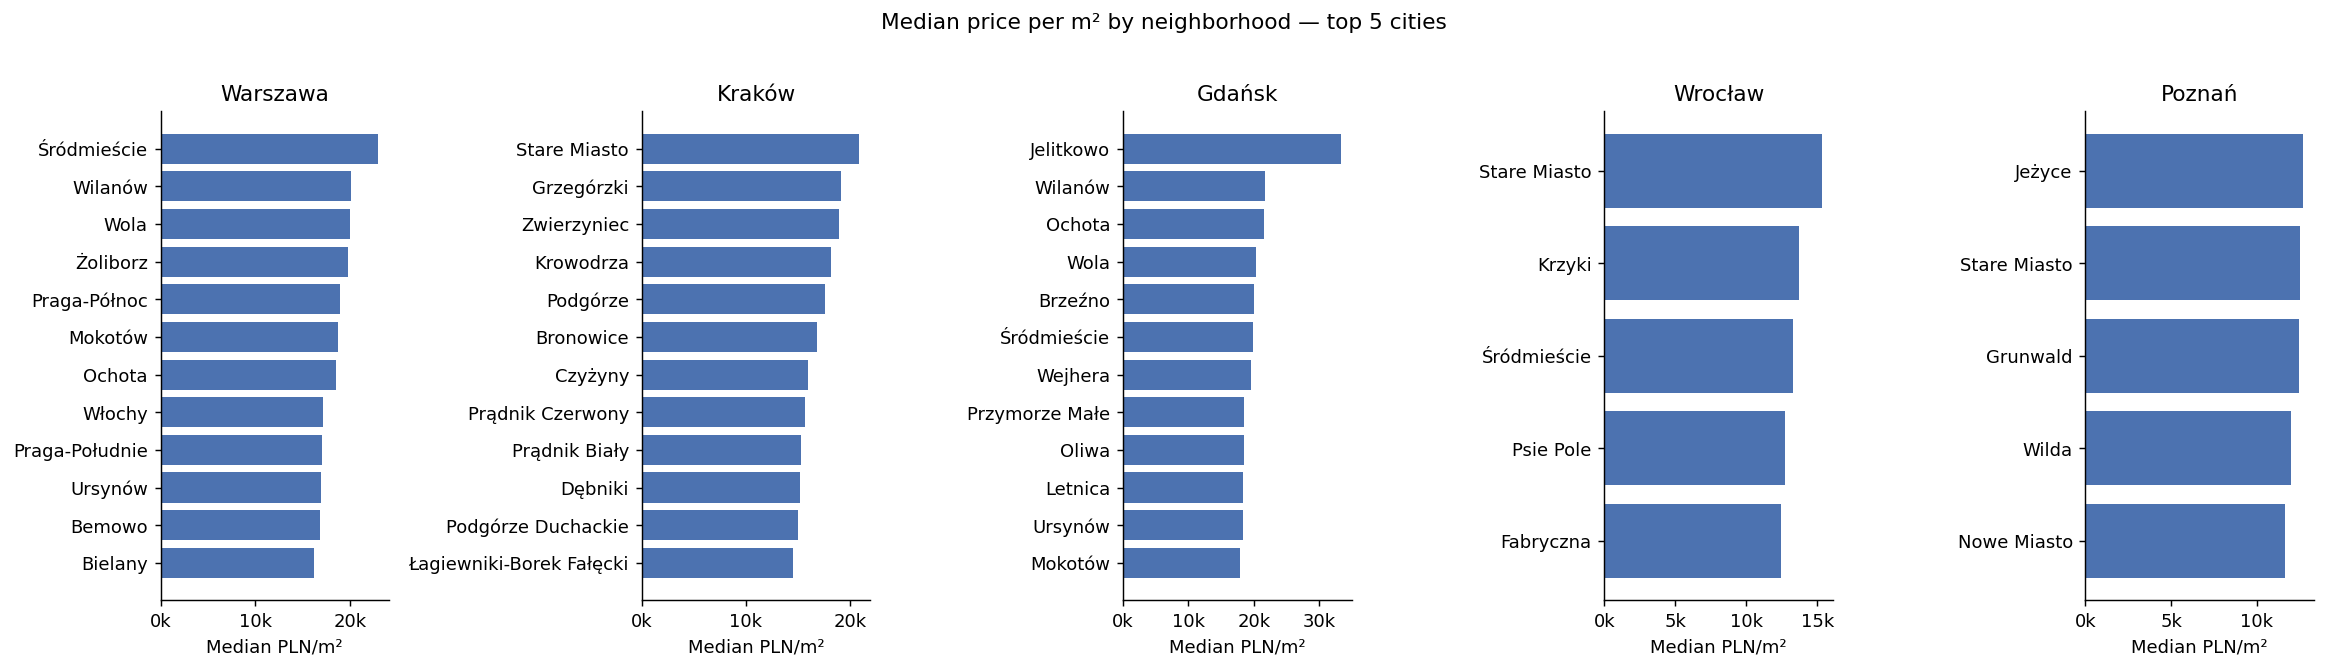

[saved] neighborhood_prices.png


In [ ]:
top_cities = ["Warszawa", "Kraków", "Gdańsk", "Wrocław", "Poznań"]

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, city in zip(axes, top_cities):
    nb_stats = (
        df[(df["city"] == city) & df["neighborhood"].notna()]
        .groupby("neighborhood")["price_per_m2"]
        .agg(median="median", count="count")
        .query("count >= 5")
        .sort_values("median", ascending=True)
        .tail(12)
        .reset_index()
    )
    ax.barh(nb_stats["neighborhood"], nb_stats["median"], color="#4C72B0", edgecolor="none")
    ax.set_title(city)
    ax.set_xlabel("Median PLN/m²")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))

fig.suptitle("Median price per m² by neighborhood — top 5 cities", y=1.02)
plt.tight_layout()
plt.savefig("neighborhood_prices.png", bbox_inches="tight")
plt.show()
print("[saved] neighborhood_prices.png")


## Feature Engineering


In [ ]:
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()

# 0.6% null neighborhood → wypełniamy nazwą miasta
df_model["neighborhood"] = df_model["neighborhood"].fillna(df_model["city"])

# brakujące rooms/floor → mediana per miasto
df_model["rooms"] = df_model.groupby("city")["rooms"].transform(lambda x: x.fillna(x.median()))
df_model["floor"] = df_model.groupby("city")["floor"].transform(lambda x: x.fillna(x.median()))

le_city         = LabelEncoder()
le_neighborhood = LabelEncoder()

df_model["city_enc"]         = le_city.fit_transform(df_model["city"])
df_model["neighborhood_enc"] = le_neighborhood.fit_transform(df_model["neighborhood"])
df_model["is_private_owner"] = df_model["is_private_owner"].astype(int)

FEATURES = ["area_m2", "rooms", "floor", "city_enc", "neighborhood_enc", "is_private_owner"]
TARGET   = "log_price"

X = df_model[FEATURES]
y = df_model[TARGET]

print(f"X shape : {X.shape}")
print(f"Features: {FEATURES}")
print()
print(X.describe().to_string())


X shape : (28310, 6)
Features: ['area_m2', 'rooms', 'floor', 'city_enc', 'neighborhood_enc', 'is_private_owner']

       area_m2    rooms    floor  city_enc  neighborhood_enc  is_private_owner
count 28310.00 28310.00 28310.00  28310.00          28310.00          28310.00
mean     56.70     2.56     2.37      8.83            188.31              0.15
std      24.32     0.92     1.99      4.31            103.68              0.35
min      15.00     1.00     0.00      0.00              0.00              0.00
25%      40.30     2.00     1.00      5.00             94.00              0.00
50%      51.90     2.00     2.00     11.00            208.00              0.00
75%      66.00     3.00     3.00     12.00            277.00              0.00
max     250.00     5.00     9.00     14.00            336.00              1.00


## Model — XGBoost Regression
### Train / test split


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print(f"Train : {X_train.shape[0]} rows")
print(f"Test  : {X_test.shape[0]} rows")


Train : 22648 rows
Test  : 5662 rows


### Training


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=SEED,
    n_jobs=-1,
    verbosity=0,
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred_log = model.predict(X_test)
y_pred     = np.expm1(y_pred_log)
y_true     = np.expm1(y_test)

mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f"{'Metric':<10} {'Value':>12}")
print(f"{'-'*23}")
print(f"{'MAE':<10} {mae:>11,.0f} PLN")
print(f"{'MAPE':<10} {mape:>10.1f} %")
print(f"{'R²':<10} {r2:>12.3f}")
print()
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score

model = XGBRegressor(
    n_estimators=800,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    random_state=SEED,
    n_jobs=-1,
    verbosity=0,
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred_log = model.predict(X_test)
y_pred     = np.expm1(y_pred_log)
y_true     = np.expm1(y_test)

mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f"{'Metric':<10} {'Value':>12}")
print(f"{'-'*23}")
print(f"{'MAE':<10} {mae:>11,.0f} PLN")
print(f"{'MAPE':<10} {mape:>10.1f} %")
print(f"{'R²':<10} {r2:>12.3f}")



Metric            Value
-----------------------
MAE            136,197 PLN
MAPE             15.7 %
R²                0.790

Metric            Value
-----------------------
MAE            136,197 PLN
MAPE             15.7 %
R²                0.790


### Actual vs predicted


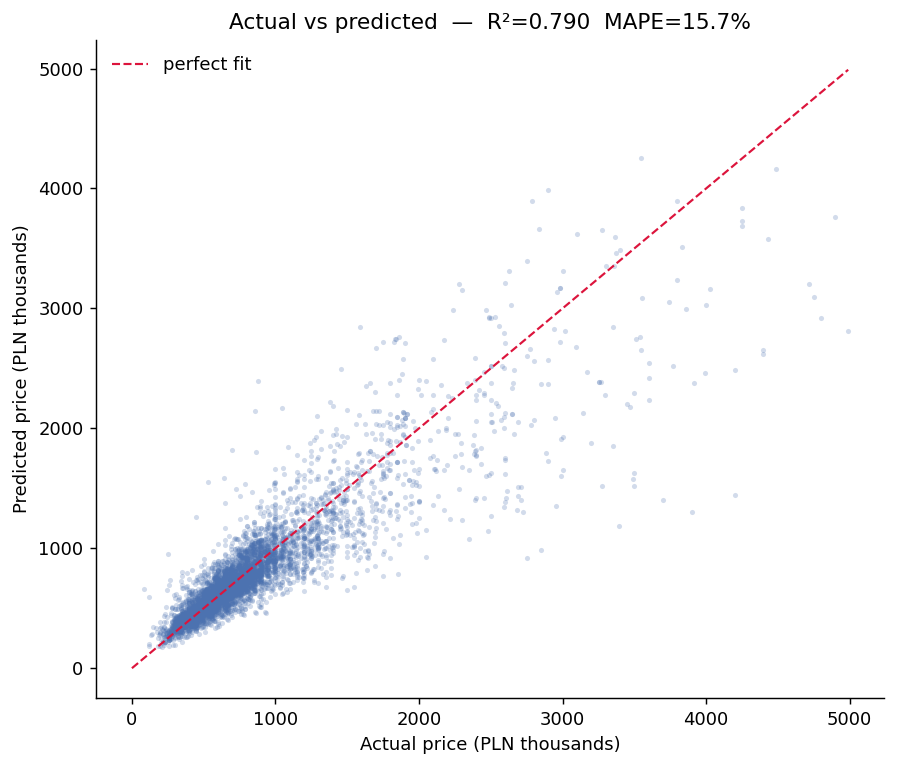

[saved] actual_vs_predicted.png


In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(y_true / 1_000, y_pred / 1_000, alpha=0.25, s=8, linewidths=0, color="#4C72B0")
lim = max(y_true.max(), y_pred.max()) / 1_000
ax.plot([0, lim], [0, lim], color="crimson", linewidth=1.2, linestyle="--", label="perfect fit")
ax.set_xlabel("Actual price (PLN thousands)")
ax.set_ylabel("Predicted price (PLN thousands)")
ax.set_title(f"Actual vs predicted  —  R²={r2:.3f}  MAPE={mape:.1f}%")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("actual_vs_predicted.png", bbox_inches="tight")
plt.show()
print("[saved] actual_vs_predicted.png")


## SHAP — Feature Importance


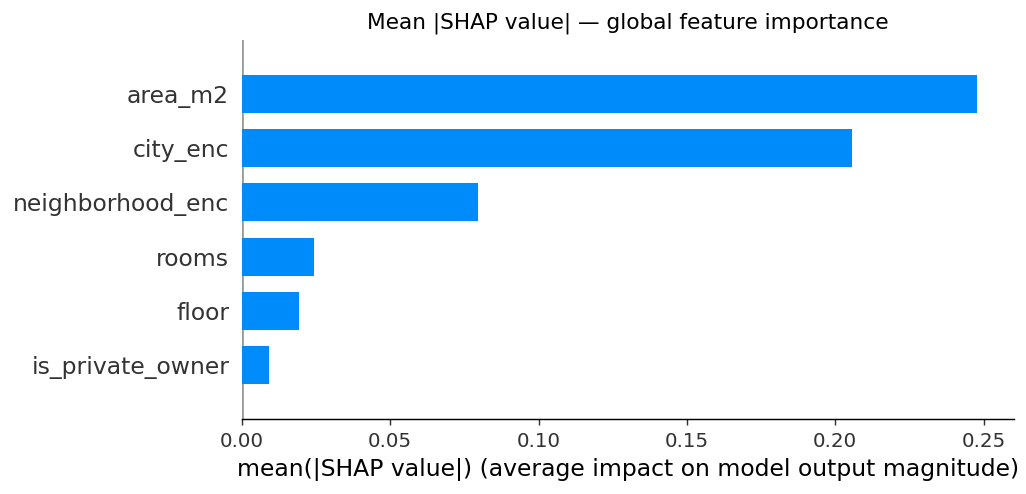

[saved] shap_importance.png


In [ ]:
import shap

explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar", feature_names=FEATURES, show=False)
plt.title("Mean |SHAP value| — global feature importance")
plt.tight_layout()
plt.savefig("shap_importance.png", bbox_inches="tight")
plt.show()
print("[saved] shap_importance.png")


### SHAP beeswarm — direction of impact


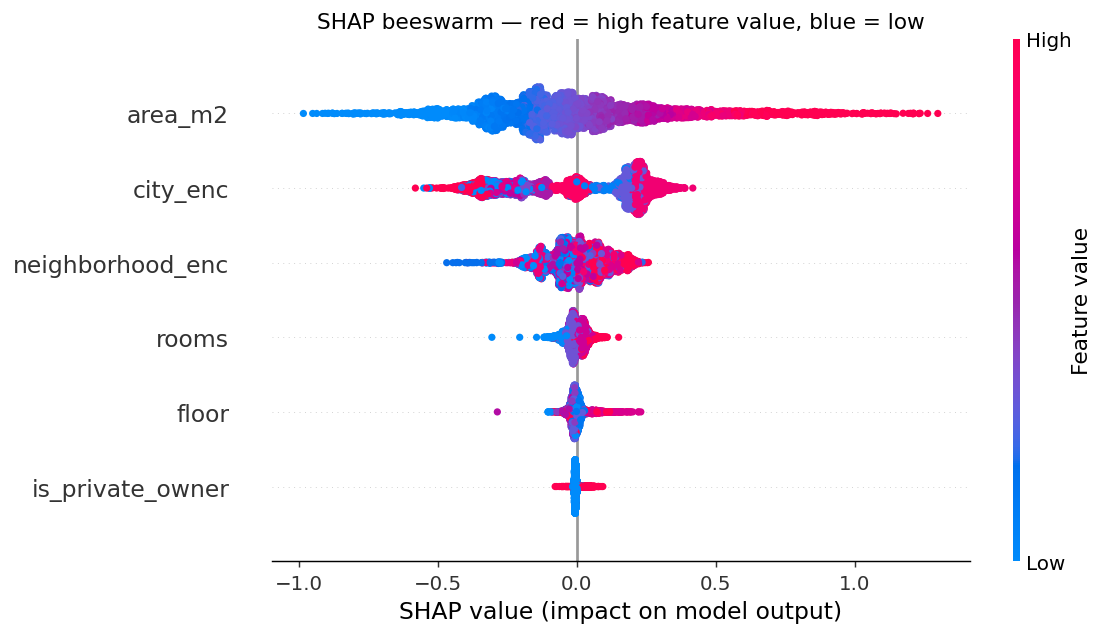

[saved] shap_beeswarm.png


In [ ]:
shap.summary_plot(shap_values, X_test, feature_names=FEATURES, show=False, plot_size=(9, 5))
plt.title("SHAP beeswarm — red = high feature value, blue = low")
plt.tight_layout()
plt.savefig("shap_beeswarm.png", bbox_inches="tight")
plt.show()
print("[saved] shap_beeswarm.png")


## Per-city error analysis


In [ ]:
city_mae = []
for city in sorted(df_model["city"].unique()):
    mask = df_model.loc[X_test.index, "city"] == city
    if mask.sum() < 10:
        continue
    mae_c = mean_absolute_error(y_true[mask], y_pred[mask])
    city_mae.append({"city": city, "n": int(mask.sum()), "mae_pln": int(mae_c)})

city_mae_df = pd.DataFrame(city_mae).sort_values("mae_pln")

print(f"{'City':<12} {'N':>5}  {'MAE (PLN)':>12}")
print("-" * 32)
for _, row in city_mae_df.iterrows():
    print(f"{row['city']:<12} {row['n']:>5}  {row['mae_pln']:>12,}")
print("-" * 32)
print(f"{'Overall':<12} {len(y_true):>5}  {int(mae):>12,}")


City             N     MAE (PLN)
--------------------------------
Łódź           490        65,962
Lublin         159        67,137
Kielce         152        78,901
Rzeszów        109        89,794
Białystok      154        89,926
Bydgoszcz      164       102,507
Szczecin       176       108,318
Katowice       113       109,805
Toruń          133       117,547
Poznań         377       124,490
Olsztyn         98       126,594
Wrocław        744       141,039
Kraków         913       156,279
Warszawa      1485       160,473
Gdańsk         395       211,000
--------------------------------
Overall       5662       136,196


**Model:** XGBoost regression on 6 features scraped from listing list-view  
**R² = 0.790 · MAE = 136,197 PLN · MAPE = 15.7%**

Key findings:
- `area_m2` is the strongest single predictor — monotonic, high SHAP spread
- `city_enc` explains nearly as much variance as area — location dominates pricing
- `neighborhood_enc` adds meaningful signal (3rd in SHAP) — justifies district-level scraping strategy
- `is_private_owner` has minimal but directionally correct effect
- Cheaper, homogeneous markets (Łódź, Lublin) → MAE ~66–67k PLN
- Gdańsk → MAE 211k PLN driven by high-variance premium districts (Jelitkowo 30k+/m²)

**Ceiling:** list-view data omits year built, building type, condition and floor finish — features available only on individual listing pages. Scraping those would likely push R² above 0.85.


## Export — model artefacts for Streamlit app


In [ ]:
import joblib, json, shutil
from google.colab import files

EXPORT_DIR = Path("model_artefacts")
EXPORT_DIR.mkdir(exist_ok=True)

joblib.dump(model,           EXPORT_DIR / "xgb_model.joblib")
joblib.dump(le_city,         EXPORT_DIR / "le_city.joblib")
joblib.dump(le_neighborhood, EXPORT_DIR / "le_neighborhood.joblib")

city_neighborhoods: dict[str, list[str]] = (
    df_model.groupby("city")["neighborhood"]
    .apply(lambda x: sorted(x.dropna().unique().tolist()))
    .to_dict()
)
with open(EXPORT_DIR / "city_neighborhoods.json", "w", encoding="utf-8") as f:
    json.dump(city_neighborhoods, f, ensure_ascii=False, indent=2)

meta = {
    "features":    FEATURES,
    "rooms_range": [int(df_model["rooms"].min()), int(df_model["rooms"].max())],
    "floor_range": [int(df_model["floor"].min()), int(df_model["floor"].max())],
    "area_range":  [float(df_model["area_m2"].min()), float(df_model["area_m2"].max())],
}
with open(EXPORT_DIR / "meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("Saved artefacts:")
for p in sorted(EXPORT_DIR.iterdir()):
    print(f"  {p.name}  ({p.stat().st_size / 1024:.1f} KB)")

shutil.make_archive("model_artefacts", "zip", EXPORT_DIR)
files.download("model_artefacts.zip")


Saved artefacts:
  city_neighborhoods.json  (8.3 KB)
  le_city.joblib  (0.6 KB)
  le_neighborhood.joblib  (5.2 KB)
  meta.json  (0.2 KB)
  xgb_model.joblib  (3218.3 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Streamlit App

Model artefacts exported to `model_artefacts.zip`:
- `xgb_model.joblib` — trained XGBoost regressor
- `le_city.joblib` / `le_neighborhood.joblib` — fitted LabelEncoders
- `city_neighborhoods.json` — city → neighborhood mapping for UI dropdowns
- `meta.json` — feature ranges for input validation

Run locally after extracting artefacts:
pip install streamlit xgboost scikit-learn joblib pandas numpy matplotlib;
streamlit run app.py
